<a href="https://colab.research.google.com/github/Nxpze/essencial-project1/blob/main/Clinic_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Library ทั้งหมดที่ใช้ในโปรเจคนี้

In [1]:
from datetime import datetime, timedelta, time, date
import random
import sqlite3
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os, shutil
import matplotlib.font_manager as fm
import seaborn as sns


random.seed(42)

# สร้างคลาสและฟังก์ชั่นสำหรับการพัฒนาระบบ

In [2]:
# 1. CLASS DEFINITIONS & TRIAGE LOGIC

class Patient:
  def __init__(self, patient_id, fullname, dob, phone_number, allergies="ไม่มี", underlying_disease="ไม่มี",):
    self.patient_id = patient_id
    self.fullname = fullname
    self.dob = dob
    self.phone_number = phone_number
    self.allergies = allergies
    self.underlying_disease = underlying_disease
    self.age = self.age_cal()

# คำนวณอายุจากวันเกิด
  def age_cal(self):
    birthdate = datetime.strptime(self.dob, "%Y-%m-%d").date()
    today = datetime.today().date()
    age = today.year - birthdate.year - ((today.month, today.day) < (birthdate.month, birthdate.day))
    return age

class Queue:
  def __init__(self, queue_id, patient_id, queue_number, symptoms, urgency_level, arrival_time):
    self.queue_id = queue_id
    self.patient_id = patient_id
    self.queue_number = queue_number
    self.symptoms = symptoms
    self.urgency_level = urgency_level  # Red, Yellow, Green, White
    self.arrival_time = arrival_time

# ตั้งค่าเวลารอคอยสูงสุด
    self.waiting_time_threshold = self.get_threshold_by_color()
    self.priority_score = self.get_priority_score()
    self.waiting_time = 0
    self.status = "In Queue"
    self.alert_status = "ปกติ"

# กำหนดเกณฑ์เวลารอคอยสูงสุดตามสีเคส
  def get_threshold_by_color(self):
      thresholds = {
        "Red": 0,  # ตรวจทันที
        "Yellow": 15,  # เร่งด่วน รอได้ไม่เกิน 15 นาที
        "Green": 30,  # ไม่เร่งด่วน รอได้ไม่เกิน 30 นาที
        "White": 45,  # ไม่ฉุกเฉิน รอได้ไม่เกิน 45 นาที
        }
      return thresholds.get(self.urgency_level, 30)

# คะแนนสำหรับ Sort Queue (เรียง Red -> Yellow -> Green -> White)
  def get_priority_score(self):
      scores = {"Red": 1, "Yellow": 2, "Green": 3, "White": 4}
      return scores.get(self.urgency_level, 99)

# ตรวจสอบเวลารอคอยจริงเทียบกับ Arrival Time
  def check_waiting_status(self, current_time):
      elapsed_minutes = (current_time - self.arrival_time).total_seconds() / 60
      self.waiting_time = round(elapsed_minutes, 1)

# เตือนเมื่อรอนานเกิน 30 นาที
      if self.waiting_time >= 30 and self.urgency_level != "Red":
         self.alert_status = "ต้องรีเช็ค"

# รีเช็คโดยพยาบาล หากอาการแย่ลงจะ Fast-track เป็น Red
  def nurse_recheck(self, condition):
      if condition == "อาการแย่ลง":
         self.urgency_level = "Red"
         self.priority_score = 1
         self.alert_status = "ดันคิวทันที (Fast-track)"
         self.waiting_time_threshold = 0
      else:
         self.alert_status = "รีเช็คแล้ว อาการคงเดิม"

# สิ้นสุดการตรวจรักษา -> เปลี่ยนสถานะเป็น Return Case
  def complete_examination(self):
      self.status = "Return Case"


class MedicalRecord:
    DOCTOR = {
        "DOC001": {
          "doctor_name": "นพ. สมชาย ใจดี",
          "specialization": "อายุรกรรม"
       },
        "DOC002": {
          "doctor_name": "พญ. วิภาดา รักษาดี",
          "specialization": "กุมารเวชศาสตร์ (หมอเด็ก)"
       },
        "DOC003": {
         "doctor_name": "นพ. ธนกฤต เก่งกาจ",
         "specialization": "ศัลยกรรมกระดูกและข้อ"
       }
             }
    def __init__(self, record_id, patient_id, doctor_id, record_date, diagnosis, status, prescribed_meds, ):
      self.record_id = record_id
      self.patient_id = patient_id

      doctor_info = self.DOCTOR.get(doctor_id,
       {"doctor_name": "ไม่พบข้อมูลแพทย์",
        "specialization": "ไม่ระบุ"
        })

      self.doctor_id = doctor_id
      self.doctor_name = doctor_info.get("doctor_name")
      self.doctor_specialization = doctor_info.get("specialization")
      self.record_date = record_date
      self.diagnosis = diagnosis
      self.status = status
      self.prescribed_meds = prescribed_meds



class Bill:
  def __init__(self, bill_id, record_id, patient_id, treatment_fee, medication_fee, status):
    self.bill_id = bill_id
    self.record_id = record_id
    self.patient_id = patient_id
    self.treatment_fee = treatment_fee
    self.medication_fee = medication_fee
    self.total_payment = self.calculate_total_payment()
    self.status = status

  def calculate_total_payment(self):
      return round(self.treatment_fee + self.medication_fee, 2)



# 2. HELPER FUNCTIONS FOR TRIAGE & SORTING
# จัดเรียงคิวตาม Priority Score
def sort_queue_by_triage(queue_list):
    return sorted(queue_list,key=lambda q: (q.priority_score, q.arrival_time),)

# 3. WORKFLOW RUNNER (เริ่มคัดกรอง -> จบที่ RETURN CASE)
# จำลองผู้ป่วยเข้ามา 4 ราย

patients_data = [
    ("P001", "กิตติ มีสุข", "1995-05-20", "0811112222", "ไม่มี", "เบาหวาน"),
    ("P002", "นภา มั่นคง", "2018-09-12", "0822223333", "ยาพารา", "ไม่มี"),
    ("P003", "สมชาย เจริญ", "1970-01-01", "0833334444", "ไม่มี", "ความดัน"),
    ("P004", "วิภา รุ่งเรือง", "1988-11-30", "0844445555", "อาหารทะเล", "ไม่มี"),]

patients_dict = {}
for patient_id, name, dob, phone, allergy, disease in patients_data:
    patients_dict[patient_id] = Patient(patient_id, name, dob, phone, allergy, disease)

# สร้างคิวและคัดกรองสี
sample_symptoms = [
    ("P001", "ไอ มีน้ำมูก", "Green"),
    ("P002", "ขอใบรับรองแพทย์", "White"),
    ("P003", "หมดสติ แน่นหน้าอก", "Red"),
    ("P004", "ปวดท้องเกร็ง ไข้สูง", "Yellow"),]

start_time = datetime(2026, 8, 23, 9, 0, 0)
queue_list = []

print("=== 1. คัดกรองผู้ป่วยและสร้างคิว ===")
for i, (patient_id, symptom, color) in enumerate(sample_symptoms, 1):
    arr_time = start_time + timedelta(minutes=i * 5)
    q = Queue(f"Q{i:03d}", patient_id, f"A-{i:03d}", symptom, color, arr_time)
    queue_list.append(q)
    print(f"คิว {q.queue_number} | รหัสผู้ป่วย: {q.patient_id} ({patients_dict[patient_id].fullname}) | สี: {q.urgency_level} | เวลามาถึง: {q.arrival_time.strftime('%H:%M')}")

# จัดเรียงคิวตามระดับความรุนแรง
print("\n=== 2. จัดเรียงลำดับคิวตามความรุนแรง ===")
queue_list = sort_queue_by_triage(queue_list)
for pos, q in enumerate(queue_list, 1):
    print(f"ลำดับที่ {pos}: คิว {q.queue_number} (เคสสี {q.urgency_level})")

# จำลองการเช็คเวลารอคอยและการรีเช็คโดยพยาบาล
print("\n=== 3. ประเมินเวลารอคอย และ Re-evaluation ===")
current_sim_time = start_time + timedelta(minutes=40)

for q in queue_list:
    q.check_waiting_status(current_sim_time)

    # เพิ่มการแสดงผลเวลารอคอยล่าสุดแบบชัดเจน
    print(f"เวลารอคอยล่าสุด ณ เวลา {current_sim_time.strftime('%H:%M')} น. | "
          f"คิว: {q.queue_number} | เวลาที่รอไปแล้ว: {q.waiting_time} นาที | "
          f"สถานะเตือน: {q.alert_status}")

# สุ่มจำลองเคสปวดท้อง (P004) มีอาการแย่ลงเพื่อทดสอบ Fast-track
    if q.alert_status == "ต้องรีเช็ค":
       condition = "อาการแย่ลง" if q.patient_id == "P004" else "อาการคงเดิม"
       q.nurse_recheck(condition)
       print(f"คิว {q.queue_number} ผลรีเช็คพยาบาล: {condition} -> สถานะใหม่: {q.urgency_level} ({q.alert_status})")

# จัดลำดับคิวใหม่อีกครั้งหลังมี Fast-track
queue_list = sort_queue_by_triage(queue_list)

# เข้าห้องตรวจ บันทึก Medical Record
print("\n=== 4. ตรวจรักษาและจบขั้นตอนที่ RETURN CASE ===")
completed_records = []
doctors_keys = ["DOC001", "DOC002", "DOC003"]

# แพทย์ตรวจเสร็จ เปลี่ยนสถานะเป็น Return Case
for q in queue_list:
    q.complete_examination()

# เลือกหมอและบันทึกเวชระเบียน
    doc_id = random.choice(doctors_keys)
    rec = MedicalRecord(
      record_id=f"REC-{q.queue_id}",
      patient_id=q.patient_id,
      doctor_id=doc_id,
      record_date=current_sim_time.strftime("%Y-%m-%d"),
      diagnosis=f"วินิจฉัยเคส {q.urgency_level}: {q.symptoms}",
      status=q.status, prescribed_meds="รับยาตามอาการ",)
    completed_records.append(rec)
    print(f"คิว {q.queue_number} | แพทย์ผู้ตรวจ: {rec.doctor_name} ({rec.doctor_specialization}) | สถานะเคส: {q.status}")

# 5. พบแพทย์ / วินิจฉัย
# นำข้อมูลจาก Medical Record มาใช้ในการวินิจฉัยผู้ป่วย

print("\n=== 5. พบแพทย์ / วินิจฉัย ===")

treatment_results = []

for rec in completed_records:

    # สั่งยา / นัดหัตถการ
    treatment = rec.prescribed_meds

    # ผลการรักษา
    result = random.choice(["หายขาด", "ไม่หายขาด"])

    # ตรวจสอบว่าผู้ป่วยหายขาดหรือไม่
    if result == "หายขาด":
        appointment = "ไม่ต้องนัด"
    else:
        appointment = "return ใบนัด"

    # เก็บข้อมูลผลการรักษา
    treatment_results.append({
        "record_id": rec.record_id,
        "patient_id": rec.patient_id,
        "treatment": treatment,
        "treatment_result": result,
        "appointment": appointment
    })

    print(
        f"ผู้ป่วย: {rec.patient_id} | "
        f"สั่งยา/นัดหัตถการ: {treatment} | "
        f"ผลการรักษา: {result} | "
        f"{appointment}"
    )


# 6. Bills
# สร้าง Bill หลังจากจบขั้นตอนการรักษา

print("\n=== 6. Bills ===")

completed_bills = []

for i, rec in enumerate(completed_records, 1):

    # กำหนดค่ารักษาและค่ายา
    treatment_fee = random.choice([300, 500, 800, 1000, 1500])
    medication_fee = random.choice([50, 100, 200, 300, 500])

    # สร้าง Bill ของผู้ป่วย
    bill = Bill(
        bill_id=f"BILL-{i:03d}",
        record_id=rec.record_id,
        patient_id=rec.patient_id,
        treatment_fee=treatment_fee,
        medication_fee=medication_fee,
        status="รอชำระ"
    )

    # เก็บข้อมูล Bill
    completed_bills.append(bill)

    print(
        f"ผู้ป่วย: {bill.patient_id} | "
        f"ค่ารักษา: {bill.treatment_fee} บาท | "
        f"ค่ายา: {bill.medication_fee} บาท | "
        f"รวม: {bill.total_payment} บาท"
    )

=== 1. คัดกรองผู้ป่วยและสร้างคิว ===
คิว A-001 | รหัสผู้ป่วย: P001 (กิตติ มีสุข) | สี: Green | เวลามาถึง: 09:05
คิว A-002 | รหัสผู้ป่วย: P002 (นภา มั่นคง) | สี: White | เวลามาถึง: 09:10
คิว A-003 | รหัสผู้ป่วย: P003 (สมชาย เจริญ) | สี: Red | เวลามาถึง: 09:15
คิว A-004 | รหัสผู้ป่วย: P004 (วิภา รุ่งเรือง) | สี: Yellow | เวลามาถึง: 09:20

=== 2. จัดเรียงลำดับคิวตามความรุนแรง ===
ลำดับที่ 1: คิว A-003 (เคสสี Red)
ลำดับที่ 2: คิว A-004 (เคสสี Yellow)
ลำดับที่ 3: คิว A-001 (เคสสี Green)
ลำดับที่ 4: คิว A-002 (เคสสี White)

=== 3. ประเมินเวลารอคอย และ Re-evaluation ===
เวลารอคอยล่าสุด ณ เวลา 09:40 น. | คิว: A-003 | เวลาที่รอไปแล้ว: 25.0 นาที | สถานะเตือน: ปกติ
เวลารอคอยล่าสุด ณ เวลา 09:40 น. | คิว: A-004 | เวลาที่รอไปแล้ว: 20.0 นาที | สถานะเตือน: ปกติ
เวลารอคอยล่าสุด ณ เวลา 09:40 น. | คิว: A-001 | เวลาที่รอไปแล้ว: 35.0 นาที | สถานะเตือน: ต้องรีเช็ค
คิว A-001 ผลรีเช็คพยาบาล: อาการคงเดิม -> สถานะใหม่: Green (รีเช็คแล้ว อาการคงเดิม)
เวลารอคอยล่าสุด ณ เวลา 09:40 น. | คิว: A-002 | เวลาที่รอไปแล้ว

# 4. Interactive Clinic Workflow

ส่วนนี้ **ใช้คลาส `Patient`, `Queue`, `MedicalRecord`, `Bill` และข้อมูลจำลอง `P001–P004` ของไฟล์เดิมโดยตรง** แล้วเพิ่มช่องรับข้อมูลด้วย `input()` ตามตัวอย่าง `demo.ipynb`

ลำดับการทำงาน: ค้นหา/ลงทะเบียนผู้ป่วย → กรอกอาการ → คัดกรอง Red/Yellow/Green/White → จัดคิวตามสีและเวลามาถึง → ตรวจเวลารอ/รีเช็ค → พบแพทย์ → ผลการรักษา/ใบนัด → Bill


In [3]:
# 4.1 HELPER FUNCTIONS & INTERACTIVE WORKFLOW
# ส่วนนี้เพิ่มต่อจากโค้ดเดิม โดยไม่แก้คลาสและข้อมูลจำลองด้านบน

import re

if "appointment_records" not in globals():
    appointment_records = []


def prompt_nonempty(message):
    """รับข้อความที่ห้ามเว้นว่าง"""
    while True:
        value = input(message).strip()
        if value:
            return value
        print("❌ ช่องนี้ห้ามเว้นว่าง กรุณากรอกอีกครั้ง")


def prompt_yes_no(message, default=None):
    """รับคำตอบ Y/N โดยคืนค่า True/False"""
    yes_values = {"y", "yes", "1", "true", "ใช่", "ช", "ค่ะ", "ครับ"}
    no_values = {"n", "no", "0", "false", "ไม่", "ม"}
    suffix = " [Y/N]"
    if default is True:
        suffix = " [Y/n]"
    elif default is False:
        suffix = " [y/N]"

    while True:
        answer = input(message + suffix + ": ").strip().lower()
        if not answer and default is not None:
            return default
        if answer in yes_values:
            return True
        if answer in no_values:
            return False
        print("❌ กรุณาตอบ Y หรือ N")


def prompt_choice(message, choices, default=None):
    """รับค่าจาก choices แบบไม่สนตัวพิมพ์เล็ก/ใหญ่"""
    lookup = {choice.lower(): choice for choice in choices}
    choice_text = "/".join(choices)
    while True:
        suffix = f" [{choice_text}]"
        if default:
            suffix += f" (ค่าเริ่มต้น {default})"
        answer = input(message + suffix + ": ").strip()
        if not answer and default:
            return default
        selected = lookup.get(answer.lower())
        if selected:
            return selected
        print(f"❌ กรุณาเลือก {choice_text}")


def prompt_birthdate(message="วันเกิด (YYYY-MM-DD หรือ YYYY/MM/DD): "):
    """ตรวจรูปแบบวันเกิดก่อนส่งให้ Patient class เดิม"""
    while True:
        value = input(message).strip()
        birthdate = None
        for date_format in ("%Y-%m-%d", "%Y/%m/%d"):
            try:
                birthdate = datetime.strptime(value, date_format).date()
                break
            except ValueError:
                continue
        if birthdate and birthdate <= datetime.today().date():
            # Patient class เดิมรับ YYYY-MM-DD จึงแปลงให้อัตโนมัติ
            return birthdate.strftime("%Y-%m-%d")
        print(
            "❌ วันเกิดไม่ถูกต้อง กรุณาใช้ YYYY-MM-DD หรือ YYYY/MM/DD "
            "และต้องไม่เป็นอนาคต"
        )


def prompt_phone(message="เบอร์โทรศัพท์: "):
    while True:
        phone = input(message).strip()
        digits = re.sub(r"\D", "", phone)
        if 9 <= len(digits) <= 15:
            return phone
        print("❌ เบอร์โทรศัพท์ต้องมีตัวเลข 9–15 หลัก")


def prompt_money(message, default=0.0):
    while True:
        value = input(f"{message} [ค่าเริ่มต้น {default:,.2f}]: ").strip()
        try:
            amount = float(value) if value else float(default)
            if amount < 0:
                raise ValueError
            return amount
        except ValueError:
            print("❌ กรุณากรอกจำนวนเงินตั้งแต่ 0 ขึ้นไป")


def next_id(prefix, existing_ids, width=3, separator=""):
    """สร้างรหัสถัดไปจากรหัสที่มีอยู่ โดยไม่ทับข้อมูลเดิม"""
    numbers = []
    pattern = re.compile(rf"^{re.escape(prefix)}{re.escape(separator)}(\d+)$")
    for item_id in existing_ids:
        match = pattern.match(str(item_id))
        if match:
            numbers.append(int(match.group(1)))
    number = max(numbers, default=0) + 1
    return f"{prefix}{separator}{number:0{width}d}"


def show_patient(patient):
    adult_status = "บรรลุนิติภาวะ" if patient.age >= 20 else "ยังไม่บรรลุนิติภาวะ"
    print(f"รหัสผู้ป่วย: {patient.patient_id}")
    print(f"ชื่อ-นามสกุล: {patient.fullname}")
    print(f"วันเกิด: {patient.dob} | อายุ: {patient.age} ปี ({adult_status})")
    print(f"เบอร์โทร: {patient.phone_number}")
    print(f"แพ้ยา: {patient.allergies} | โรคประจำตัว: {patient.underlying_disease}")


def find_or_register_patient():
    """Flowchart: ตรวจ P_id; ถ้าไม่พบให้ลงทะเบียนและคำนวณอายุ"""
    print("\n--- 1) ค้นหาประวัติ / ลงทะเบียนผู้ป่วย ---")
    requested_id = input(
        "กรอกรหัสผู้ป่วย P_id (ทดลอง P001–P004 หรือกด Enter สำหรับผู้ป่วยใหม่): "
    ).strip().upper()

    if requested_id and requested_id in patients_dict:
        patient = patients_dict[requested_id]
        print("\n✅ พบผู้ป่วยเดิมในระบบ")
        show_patient(patient)
        return patient

    if requested_id:
        if not re.fullmatch(r"[A-Z0-9_-]+", requested_id):
            print("⚠️ รูปแบบ P_id ไม่ถูกต้อง ระบบจะสร้างรหัสใหม่ให้")
            requested_id = ""
        else:
            print(f"\nไม่พบ {requested_id} — เข้าสู่การลงทะเบียนผู้ป่วยใหม่")
    else:
        print("\nเข้าสู่การลงทะเบียนผู้ป่วยใหม่")

    patient_id = requested_id or next_id("P", patients_dict.keys())
    fullname = prompt_nonempty("ชื่อ-นามสกุล: ")
    dob = prompt_birthdate()
    phone = prompt_phone()
    allergies = input("ประวัติแพ้ยา (กด Enter หากไม่มี): ").strip() or "ไม่มี"
    disease = input("โรคประจำตัว (กด Enter หากไม่มี): ").strip() or "ไม่มี"

    patient = Patient(patient_id, fullname, dob, phone, allergies, disease)
    patients_dict[patient_id] = patient
    print("\n✅ ลงทะเบียนสำเร็จ")
    show_patient(patient)
    return patient


def triage_from_flowchart():
    """คัดกรองจากระดับรุนแรงที่สุดลงมาตาม flowchart"""
    print("\n--- 2) คัดกรองความเร่งด่วนตาม Flowchart ---")
    if prompt_yes_no("หัวใจหยุดเต้น ไม่หายใจ ช็อก หรือหมดสติหรือไม่", default=False):
        return "Red"
    if prompt_yes_no(
        "หายใจลำบากปานกลาง เจ็บแน่นหน้าอกมาก หรือปวดท้องรุนแรงหรือไม่",
        default=False,
    ):
        return "Yellow"
    if prompt_yes_no(
        "ไข้หวัด ปวดศีรษะเล็กน้อย หรือมีแผลหรือไม่",
        default=False,
    ):
        return "Green"
    if prompt_yes_no(
        "ขอรับยาต่อเนื่อง หรืออื่น ๆ หรือไม่",
        default=False,
    ):
        return "White"

    print("⚠️ Case ไม่สามารถระบุได้ กรุณาให้ผู้มีประสบการณ์ตัดสินใจ")
    return prompt_choice("เจ้าหน้าที่ประเมินเป็นเคสสีใด", ["Red", "Yellow", "Green", "White"])


def create_interactive_queue(patient, symptoms, urgency_level):
    queue_id = next_id("Q", [queue.queue_id for queue in queue_list])
    queue_number = next_id(
        "A", [queue.queue_number for queue in queue_list], separator="-"
    )
    queue = Queue(
        queue_id,
        patient.patient_id,
        queue_number,
        symptoms,
        urgency_level,
        datetime.now(),
    )
    queue_list.append(queue)
    queue_list[:] = sort_queue_by_triage(queue_list)
    return queue


def show_active_queue(current_time=None):
    """อัปเดตเวลารอและแสดงเฉพาะคิวที่ยังรอตรวจ"""
    current_time = current_time or datetime.now()
    active = [queue for queue in queue_list if queue.status == "In Queue"]
    for queue in active:
        queue.check_waiting_status(current_time)
    active = sort_queue_by_triage(active)

    print("\nลำดับคิวที่กำลังรอตรวจ")
    if not active:
        print("- ไม่มีคิวรอตรวจ")
    for position, queue in enumerate(active, 1):
        print(
            f"{position}. {queue.queue_number} | ผู้ป่วย {queue.patient_id} | "
            f"สี {queue.urgency_level} | รอ {queue.waiting_time:.1f} นาที | {queue.alert_status}"
        )
    return active


def recheck_if_over_threshold(queue, current_time=None):
    """Flowchart: ถ้ารอเกิน threshold ต้องรีเช็คและ sort queue ใหม่"""
    current_time = current_time or datetime.now()
    queue.check_waiting_status(current_time)

    if queue.urgency_level == "Red":
        print("🚨 เคส Red ต้องเข้าตรวจทันที")
        return queue

    if queue.waiting_time <= queue.waiting_time_threshold:
        print(
            f"✅ เวลารอ {queue.waiting_time:.1f} นาที ยังไม่เกินเกณฑ์ "
            f"{queue.waiting_time_threshold} นาที"
        )
        return queue

    print(
        f"⚠️ รอ {queue.waiting_time:.1f} นาที เกินเกณฑ์ "
        f"{queue.waiting_time_threshold} นาที"
    )
    print("🔁 เรียกประเมินอาการซ้ำ อัปเดต Case และ Sort Queue ใหม่")
    updated_symptoms = input(
        f"อาการล่าสุด [กด Enter เพื่อใช้ข้อมูลเดิม: {queue.symptoms}]: "
    ).strip()
    if updated_symptoms:
        queue.symptoms = updated_symptoms

    # วนกลับไปตรวจเงื่อนไข Red → Yellow → Green → White ตาม flowchart อีกครั้ง
    queue.urgency_level = triage_from_flowchart()
    queue.priority_score = queue.get_priority_score()
    queue.waiting_time_threshold = queue.get_threshold_by_color()
    queue.alert_status = "รีเช็คแล้ว อัปเดต Case และจัดคิวใหม่"
    # เริ่มนับรอบเฝ้าระวังใหม่หลังประเมินซ้ำ
    queue.arrival_time = current_time
    queue.waiting_time = 0
    queue_list[:] = sort_queue_by_triage(queue_list)
    print(f"✅ Case หลังประเมินซ้ำ: {queue.urgency_level} | {queue.alert_status}")
    return queue


def prompt_appointment_date():
    default_date = (datetime.today().date() + timedelta(days=7)).strftime("%Y-%m-%d")
    while True:
        value = input(
            f"วันที่นัด (YYYY-MM-DD หรือ YYYY/MM/DD) "
            f"[ค่าเริ่มต้น {default_date}]: "
        ).strip()
        value = value or default_date
        appointment_date = None
        for date_format in ("%Y-%m-%d", "%Y/%m/%d"):
            try:
                appointment_date = datetime.strptime(value, date_format).date()
                break
            except ValueError:
                continue
        if appointment_date and appointment_date >= datetime.today().date():
            return appointment_date.strftime("%Y-%m-%d")
        print(
            "❌ วันนัดต้องเป็นวันนี้หรืออนาคต และใช้รูปแบบ "
            "YYYY-MM-DD หรือ YYYY/MM/DD"
        )


def run_clinic_workflow():
    """รับผู้ป่วยหนึ่งรายตั้งแต่เริ่มต้นจนออก Bill ตาม flowchart"""
    print("\n" + "=" * 68)
    print("🏥 ระบบบริการผู้ป่วยตาม Clinic Flowchart")
    print("=" * 68)

    # 1. Patient
    patient = find_or_register_patient()

    # 2. Symptoms & Triage
    symptoms = prompt_nonempty("\nกรอกอาการสำคัญ: ")
    urgency_level = triage_from_flowchart()
    registered_queue = create_interactive_queue(patient, symptoms, urgency_level)
    print(
        f"\n🎫 ออกคิว {registered_queue.queue_number} สำเร็จ | "
        f"สี {registered_queue.urgency_level} | "
        f"เกณฑ์รอสูงสุด {registered_queue.waiting_time_threshold} นาที"
    )

    # 3. Sort Queue & Waiting-time Re-evaluation
    while True:
        active_queues = show_active_queue()
        if not active_queues:
            raise RuntimeError("ไม่พบคิวที่กำลังรอตรวจ")
        queue = active_queues[0]
        queue.check_waiting_status(datetime.now())
        is_over_threshold = (
            queue.urgency_level != "Red"
            and queue.waiting_time > queue.waiting_time_threshold
        )
        if is_over_threshold:
            recheck_if_over_threshold(queue)
            continue
        break

    # เรียกคิวแรกหลัง Sort Case → Sort Queue ตามสีและ arrival_time
    patient = patients_dict[queue.patient_id]
    print(
        f"\n📣 เรียกคิวตามลำดับ: {queue.queue_number} | "
        f"สี {queue.urgency_level} | ผู้ป่วย {patient.fullname}"
    )
    input("\nกด Enter เมื่อพร้อมส่งผู้ป่วยเข้าห้องตรวจ...")

    # 4. Doctor Examination & Medical Record
    print("\n--- 3) พบแพทย์ / วินิจฉัย ---")
    for doctor_id, doctor_info in MedicalRecord.DOCTOR.items():
        print(
            f"{doctor_id}: {doctor_info['doctor_name']} "
            f"({doctor_info['specialization']})"
        )
    doctor_id = prompt_choice(
        "เลือกแพทย์",
        list(MedicalRecord.DOCTOR.keys()),
        default="DOC001",
    )
    diagnosis = prompt_nonempty("ผลการวินิจฉัย: ")
    prescribed_meds = input("สั่งยา / นัดหัตถการ (กด Enter หากไม่มี): ").strip()
    prescribed_meds = prescribed_meds or "ไม่มีการสั่งยา / นัดหัตถการ"

    queue.complete_examination()
    record_id = f"REC-{queue.queue_id}"
    record = MedicalRecord(
        record_id,
        patient.patient_id,
        doctor_id,
        datetime.today().strftime("%Y-%m-%d"),
        diagnosis,
        queue.status,
        prescribed_meds,
    )
    completed_records.append(record)

    # 5. Treatment Result & Appointment
    print("\n--- 4) ผลการรักษา ---")
    recovered = prompt_yes_no("ผู้ป่วยหายขาดหรือไม่", default=True)
    appointment = None
    if recovered:
        appointment_text = "ไม่ต้องนัด"
    else:
        print("\n--- 5) Return ใบนัด ---")
        appointment = {
            "appointment_id": next_id(
                "APT", [item["appointment_id"] for item in appointment_records]
            ),
            "patient_id": patient.patient_id,
            "fullname": patient.fullname,
            "doctor_id": doctor_id,
            "doctor_name": record.doctor_name,
            "phone_number": patient.phone_number,
            "appointment_date": prompt_appointment_date(),
            "reason": input("เหตุผลการนัด [ค่าเริ่มต้น: ติดตามผลการรักษา]: ").strip()
            or "ติดตามผลการรักษา",
        }
        appointment_records.append(appointment)
        appointment_text = (
            f"{appointment['appointment_id']} วันที่ {appointment['appointment_date']} "
            f"({appointment['reason']})"
        )

    treatment_results.append({
        "record_id": record.record_id,
        "patient_id": patient.patient_id,
        "treatment": record.prescribed_meds,
        "treatment_result": "หายขาด" if recovered else "ไม่หายขาด",
        "appointment": appointment_text,
    })

    # 6. Bill
    print("\n--- 6) Bills ---")
    treatment_fee = prompt_money("ค่ารักษา/หัตถการ", default=300.0)
    medication_fee = prompt_money("ค่ายา/เวชภัณฑ์", default=0.0)
    paid = prompt_yes_no("ชำระเงินแล้วหรือไม่", default=False)
    bill_id = next_id(
        "BILL", [bill.bill_id for bill in completed_bills], separator="-"
    )
    bill = Bill(
        bill_id,
        record.record_id,
        patient.patient_id,
        treatment_fee,
        medication_fee,
        "ชำระเงินแล้ว" if paid else "รอชำระ",
    )
    completed_bills.append(bill)

    print("\n" + "=" * 68)
    print("📋 สรุปการรับบริการ")
    print("=" * 68)
    show_patient(patient)
    print(f"คิว: {queue.queue_number} | สี: {queue.urgency_level}")
    print(f"แพทย์: {record.doctor_name} ({record.doctor_specialization})")
    print(f"วินิจฉัย: {record.diagnosis}")
    print(f"ยา/หัตถการ: {record.prescribed_meds}")
    print(f"ใบนัด: {appointment_text}")
    print(f"เลขที่ Bill: {bill.bill_id}")
    print(f"ค่ารักษา: {bill.treatment_fee:,.2f} บาท")
    print(f"ค่ายา: {bill.medication_fee:,.2f} บาท")
    print(f"รวม: {bill.total_payment:,.2f} บาท | สถานะ: {bill.status}")
    print("=" * 68)
    return {
        "patient": patient,
        "registered_queue": registered_queue,
        "queue": queue,
        "record": record,
        "appointment": appointment,
        "bill": bill,
    }


## 5. เปิดระบบรับข้อมูล

รันเซลล์ด้านล่างแล้ว Colab จะแสดงช่องให้กรอกทีละขั้นตอน หากต้องการรับผู้ป่วยรายถัดไปให้รันเซลล์นี้อีกครั้ง ข้อมูลในรอบ runtime เดียวกันจะยังอยู่


In [ ]:

clinic_result = run_clinic_workflow()



🏥 ระบบบริการผู้ป่วยตาม Clinic Flowchart

--- 1) ค้นหาประวัติ / ลงทะเบียนผู้ป่วย ---
กรอกรหัสผู้ป่วย P_id (ทดลอง P001–P004 หรือกด Enter สำหรับผู้ป่วยใหม่): P002

✅ พบผู้ป่วยเดิมในระบบ
รหัสผู้ป่วย: P002
ชื่อ-นามสกุล: นภา มั่นคง
วันเกิด: 2018-09-12 | อายุ: 7 ปี (ยังไม่บรรลุนิติภาวะ)
เบอร์โทร: 0822223333
แพ้ยา: ยาพารา | โรคประจำตัว: ไม่มี

กรอกอาการสำคัญ: ตัวร้อน ปวดหัว

--- 2) คัดกรองความเร่งด่วนตาม Flowchart ---
หัวใจหยุดเต้น ไม่หายใจ ช็อก หรือหมดสติหรือไม่ [y/N]: ื
❌ กรุณาตอบ Y หรือ N
หัวใจหยุดเต้น ไม่หายใจ ช็อก หรือหมดสติหรือไม่ [y/N]: ื
❌ กรุณาตอบ Y หรือ N
หัวใจหยุดเต้น ไม่หายใจ ช็อก หรือหมดสติหรือไม่ [y/N]: n
หายใจลำบากปานกลาง เจ็บแน่นหน้าอกมาก หรือปวดท้องรุนแรงหรือไม่ [y/N]: n
ไข้หวัด ปวดศีรษะเล็กน้อย หรือมีแผลหรือไม่ [y/N]: y

🎫 ออกคิว A-005 สำเร็จ | สี Green | เกณฑ์รอสูงสุด 30 นาที

ลำดับคิวที่กำลังรอตรวจ
1. A-005 | ผู้ป่วย P002 | สี Green | รอ 0.0 นาที | ปกติ

📣 เรียกคิวตามลำดับ: A-005 | สี Green | ผู้ป่วย นภา มั่นคง

กด Enter เมื่อพร้อมส่งผู้ป่วยเข้าห้องตรวจ...

--- 3) พบแพทย์ 

# ช่วงของการจำลองข้อมูลผ่านระบบโดยการใช้ลูป ร่วมกับ การสุ่มเข้า คลาสจนครบตามจำนวนที่ต้องการ

In [4]:
import random
import pandas as pd
from datetime import datetime, timedelta
from google.colab import files
# สร้างชื่อ - นามสกุลของผู้ป่วยเอาไปสุ่ม
first_names = [
    "สมชัย", "สมหญิง", "สมศักดิ์", "สมศรี", "สมฤดี",
    "สมหมาย", "สมบัตร", "สมปอง", "สมใจ", "สมนึก",
    "สมสวย", "สมหวัง", "สมภพ", "สมหทัย", "สมควร"
]

last_names = [
    "ประสม", "ประเสริฐ", "ประเสริฐศรี", "ประสงค์", "ประทาน",
    "ประชาชื่น", "ประเสริฐฐาน", "ประจักร", "ประสิทธิ์", "ประสาน",
    "ประชาโชค", "ประมาณตน", "ประดิษฐ์", "ประพันธ์", "ประทีป"
]

# ประวัติแพ้ยา
allergies_list = [
    "ไม่มี", "ไม่มี", "ไม่มี", "ไม่มี", "ไม่มี", "ไม่มี",  "ไม่มี", "ไม่มี",  "ไม่มี",
    "พาราเซตามอล", "เพนิซิลลิน", "แอสไพริน", "ซัลฟา" , "อัลโลพูรินอล", "เฟนิโทอิน", "ไดโคลฟีแนก"
]

# โรคประจำตัว
diseases_list = [
    "ไม่มี", "ไม่มี", "ไม่มี", "ไม่มี","ไม่มี", "ไม่มี","ไม่มี", "ไม่มี","ไม่มี", "ไม่มี",
    "เบาหวาน", "ความดันโลหิตสูง", "หอบหืด", "ไขมันในเลือดสูง", "โรคหัวใจ", "หลอดเลือดหัวใจตีบ", "HIV"
]

#สร้างตัวแปรไว้เก็บค่าที่สุ่มมาเป็น ลิสต์
patient_data = []
visit_dt = datetime.now()
today = datetime.now()

# สุ่มทุกอย่าง ชื่อ วันเกิด เบอร์ อาการ ยา โรคประจำตัว
random.seed(1)
patient_data = []

today = datetime.today().date()

for i in range(1, 301):
    # รหัส
    patient_id = f"P{i:03d}"
    # ชื่อ
    fullname = f"{random.choice(first_names)} {random.choice(last_names)}"
    # วันเกิด
    dob_dt = today - timedelta(days=random.randint(5 * 365, 90 * 365))
    dob = dob_dt.strftime("%Y-%m-%d")
    # อายุ
    age = today.year - dob_dt.year - ((today.month, today.day) < (dob_dt.month, dob_dt.day))
    # เบอร์โทร
    phone_number = f"08{random.randint(10000000, 99999999)}"
    # แพ้ยา
    allergies = random.choice(allergies_list)
    # โรคประจำตัว
    underlying_diseasel = random.choice(diseases_list)

    patient = Patient(patient_id, fullname, dob, phone_number, allergies, underlying_diseasel)

    patient_data.append(patient)

print(f"จำลองข้อมูลคนไข้ทั้งหมด: {len(patient_data)} แถว\n\n")

# ดึง Attribute จาก Object ผู้ป่วย (p) มาสร้างเป็น Dictionary ใน List Comprehension
records = [
    {
        "รหัสผู้ป่วย": p.patient_id,
        "ชื่อ - นามสกุล": p.fullname,
        "วันเกิด": p.dob,
        "อายุ": p.age,
        "เบอร์โทรศัพท์": p.phone_number,
        "ประวัติแพ้ยา": p.allergies,
        "โรคประจำตัว": p.underlying_disease
    }
    for p in patient_data  # วนทุก object ผู้ป่วยใน list ที่สุ่มได้
]

# แปลงเป็น DataFrame และบันทึกเป็นไฟล์ CSV
df_patients = pd.DataFrame(records)
display(df_patients.head())

df_patients.to_csv("patients.csv", index=False, encoding="utf-8-sig")
print("\n\n บันทึกไฟล์ CSV สำเร็จ ขนาด:", df_patients.shape)
#files.download("patients.csv")

จำลองข้อมูลคนไข้ทั้งหมด: 300 แถว




,รหัสผู้ป่วย,ชื่อ - นามสกุล,วันเกิด,อายุ,เบอร์โทรศัพท์,ประวัติแพ้ยา,โรคประจำตัว
0,P001,สมศักดิ์ ประสาน,1945-08-25,81,0818470054,ไม่มี,ไม่มี
1,P002,สมปอง ประดิษฐ์,1981-05-08,45,0873383683,ซัลฟา,ไม่มี
2,P003,สมหญิง ประจักร,2019-02-18,7,0862319252,อัลโลพูรินอล,ไม่มี
3,P004,สมหวัง ประจักร,1997-10-12,28,0840703945,ไม่มี,เบาหวาน
4,P005,สมชัย ประสม,2019-05-24,7,0897180606,ไม่มี,หอบหืด




 บันทึกไฟล์ CSV สำเร็จ ขนาด: (300, 7)


In [5]:
# จำลองข้อมูล med record

# ข้อมูลชื่อหมอในระบบ
doctors_data = [
    {"D_id": "DOC001", "doctor_name": "นพ. สมชาย ใจดี", "specialization": "อายุรกรรม", "phone": "081-111-2222"},
    {"D_id": "DOC002", "doctor_name": "พญ. วิภาดา รักษาดี", "specialization": "กุมารเวชศาสตร์ (หมอเด็ก)", "phone": "081-222-3333"},
    {"D_id": "DOC003", "doctor_name": "นพ. ธนกฤต เก่งกาจ", "specialization": "ศัลยกรรมกระดูกและข้อ", "phone": "081-333-4444"},
]

# เซ็ตอาการ ยา สถานะที่จะเป็นได้
medical_recordsl_rules = {
    "หมดสติ แน่นหน้าอก": {
        "diagnosis": "ภาวะกล้ามเนื้อหัวใจขาดเลือดเฉียบพลัน",
        "meds_list": ["Aspirin 300mg, Oxygen Therapy", "Aspirin 300mg, Nitroglycerin SL, O2"],
        "status_list": ["ส่งตัวรักษาต่อโรงพยาบาล (ออกใบรีเฟอร์)"]
    },
    "หายใจลำบากขั้นรุนแรง": {
        "diagnosis": "ภาวะหายใจล้มเหลว / หอบหืดขั้นรุนแรง",
        "meds_list": ["พ่นยา Ventolin, Oxygen Therapy", "Nebulized Salbutamol, Dexamethasone IV"],
        "status_list": ["ส่งตัวรักษาต่อโรงพยาบาล (ออกใบรีเฟอร์)"]
    },
    "ช็อกจากเสียเลือด": {
        "diagnosis": "ภาวะช็อกจากการเสียเลือดรุนแรง (Hypovolemic Shock)",
        "meds_list": ["ให้สารน้ำทางหลอดเลือดดำ (NSS/Ringer) เบื้องต้น", "IV Fluid Loading, Stop Bleeding"],
        "status_list": ["ส่งตัวรักษาต่อโรงพยาบาล (ออกใบรีเฟอร์)"]
    },
    "อุบัติเหตุร้ายแรง": {
        "diagnosis": "การบาดเจ็บรุนแรงจากอุบัติเหตุ (Major Trauma)",
        "meds_list": ["ปฐมพยาบาลเบื้องต้น ห้ามเลือด ดามคอ", "C-spine Immobilization, Morphine IV, NSS"],
        "status_list": ["ส่งตัวรักษาต่อโรงพยาบาล (ออกใบรีเฟอร์)"]
    },
    "ชักเกร็งไม่รู้สึกตัว": {
        "diagnosis": "ภาวะชักเกร็งต่อเนื่อง (Status Epilepticus)",
        "meds_list": ["Diazepam IV (เบื้องต้น), Open Airway", "Midazolam IM, Oxygen Therapy"],
        "status_list": ["ส่งตัวรักษาต่อโรงพยาบาล (ออกใบรีเฟอร์)"]
    },
    "ปวดท้องเกร็ง ไข้สูง": {
        "diagnosis": "ติดเชื้อในระบบทางเดินอาหาร / ไส้ติ่งอักเสบระยะแรก",
        "meds_list": ["Hyoscine 10mg, Buscopan, Paracetamol", "Hyoscine 10mg, Norfloxacin 400mg"],
        "status_list": ["นัดติดตามอาการ / ออกใบนัด", "ติดตามอาการ"]
    },
    "ปวดศีรษะเฉียบพลัน": {
        "diagnosis": "ปวดศีรษะไมเกรนรุนแรง / ความดันโลหิตสูงเฉียบพลัน",
        "meds_list": ["Triptan, Ibuprofen 400mg", "Ergotamine, Paracetamol 500mg"],
        "status_list": ["นัดติดตามอาการ / ออกใบนัด", "อาการดีขึ้น"]
    },
    "แผลฉีกขาดเลือดไหลไม่หยุด": {
        "diagnosis": "แผลฉีกขาด (Laceration Wound)",
        "meds_list": ["ทำแผล เย็บแผล, Tetanus Vaccine, Amoxicillin", "ทำแผล เย็บแผล, Ibuprofen 400mg"],
        "status_list": ["นัดติดตามอาการ / ออกใบนัด (ทำแผล/ตัดไหม)", "อาการดีขึ้น"]
    },
    "อาเจียนต่อเนื่อง": {
        "diagnosis": "กระเพาะอาหารและลำไส้อักเสบ (Gastroenteritis)",
        "meds_list": ["Domperidone 10mg, ORS, Paracetamol", "Ondansetron 4mg, ORS, Plasil"],
        "status_list": ["นัดติดตามอาการ / ออกใบนัด", "อาการดีขึ้น"]
    },
    "กระดูกแขนผื่นผิดรูป": {
        "diagnosis": "สงสัยกระดูกแขนหัก / ข้อต่อหลุด (Fracture/Dislocation)",
        "meds_list": ["ดามแขนชั่วคราว, Paracetamol 500mg", "Splinting, Tramadol, Paracetamol"],
        "status_list": ["นัดติดตามอาการ / ออกใบนัด", "ส่งตัวรักษาต่อโรงพยาบาล (ออกใบรีเฟอร์)"]
    },
    "ไอ มีน้ำมูก": {
        "diagnosis": "ติดเชื้อทางเดินหายใจส่วนบน (Common Cold)",
        "meds_list": ["Paracetamol 500mg, CPM", "Antihistamine, Cough Syrup"],
        "status_list": ["หายขาด", "อาการดีขึ้น"]
    },
    "ปวดศีรษะเล็กน้อย": {
        "diagnosis": "ปวดศีรษะจากความเครียด (Tension Headache)",
        "meds_list": ["Paracetamol 500mg", "Paracetamol 500mg, พักผ่อน"],
        "status_list": ["หายขาด", "อาการดีขึ้น"]
    },
    "ปวดกล้ามเนื้อ": {
        "diagnosis": "กล้ามเนื้ออักเสบ (Myalgia / Office Syndrome)",
        "meds_list": ["Ibuprofen 400mg, Muscle Relaxant", "Analgesic Cream, Paracetamol 500mg"],
        "status_list": ["หายขาด", "อาการดีขึ้น"]
    },
    "ผื่นคันตามตัว": {
        "diagnosis": "ผื่นผิวหนังอักเสบ / ลมพิษ (Dermatitis/Urticaria)",
        "meds_list": ["Cetirizine 10mg, Calamine Lotion", "Loratadine 10mg, TA Cream"],
        "status_list": ["หายขาด", "อาการดีขึ้น"]
    },
    "เจ็บคอ ถ่ายเหลว": {
        "diagnosis": "คออักเสบร่วมกับลำไส้อักเสบเบื้องต้น",
        "meds_list": ["Amoxicillin 500mg, ORS, Paracetamol", "ORS, Electrolyte, Paracetamol"],
        "status_list": ["หายขาด", "อาการดีขึ้น"]
    },
    "ขอใบรับรองแพทย์": {
        "diagnosis": "ตรวจรับรองสุขภาพทั่วไป",
        "meds_list": ["ไม่มีการจ่ายยา"],
        "status_list": ["หายขาด"]
    },
    "มาตามนัดฟังผลตรวจ": {
        "diagnosis": "ติดตามผลตรวจทางห้องปฏิบัติการ (Lab Follow-up)",
        "meds_list": ["ยาตามโรคเดิมของผู้ป่วย", "ไม่มีการจ่ายยาเพิ่มเติม"],
        "status_list": ["หายขาด", "อาการดีขึ้น"]
    },
    "ปรึกษาเรื่องสุขภาพทั่วไป": {
        "diagnosis": "ตรวจสุขภาพทั่วไปและให้คำแนะนำด้านโภชนาการ/การออกกำลังกาย",
        "meds_list": ["Multivitamin Supplement", "Vitamin C 500mg"],
        "status_list": ["หายขาด", "อาการดีขึ้น"]
    },
    "ขอรับยาเดิม": {
        "diagnosis": "ติดตามการรักษาโรคประจำตัวเดิม (Routine Refill)",
        "meds_list": ["Amlodipine 5mg (ยาความดันเดิม)", "Metformin 500mg (ยาเบาหวานเดิม)"],
        "status_list": ["หายขาด", "อาการดีขึ้น"]
    },
    "ฉีดวัคซีนตามนัด": {
        "diagnosis": "รับวัคซีนป้องกันโรคตามกำหนด",
        "meds_list": ["Influenza Vaccine, Paracetamol 500mg (สำรองเผื่อไข้)", "Hepatitis B Vaccine"],
        "status_list": ["หายขาด"]
    }
}

patients_list = df_patients.to_dict('records')
medical_records = []
today_date = datetime.now().date()

random.seed(1)
medical_records = []

# สุ่ม
symptoms_list = list(medical_recordsl_rules.keys())

for i in range(1, 1001):
    record_id = f"T{i:03d}"

    # สุ่มคนไข้ (Object) และหมอ
    patient = random.choice(patient_data)
    doctor = random.choice(doctors_data)

    patient_id = patient.patient_id
    doctor_id = doctor["D_id"] if isinstance(doctor, dict) else doctor.doctor_id

    # 💡 จุดที่แก้ไข: สุ่มอาการจากรายการ symptoms_list โดยตรงเพื่อให้กระจายครบทุกโรค
    symptom = random.choice(symptoms_list)

    rules_dict = medical_recordsl_rules
    if symptom in rules_dict:
        rule = rules_dict[symptom]
        diagnosis = rule["diagnosis"]
        meds = random.choice(rule["meds_list"])
        status = random.choice(rule["status_list"])
    else:
        diagnosis = "ไม่ระบุ"
        meds = "Paracetamol 500mg"
        status = "หายขาด"

    # สุ่มเวลารักษา
    treatment_date_dt = datetime.combine(today, datetime.min.time())
    random_hours = random.randint(8, 16)
    random_minutes = random.randint(0, 59)
    random_seconds = random.randint(0, 59)
    treatment_time = treatment_date_dt.replace(
        hour=random_hours, minute=random_minutes, second=random_seconds
    ).strftime("%Y-%m-%d %H:%M:%S")

    # สร้าง Object รายการรักษา
    record = MedicalRecord(
        record_id=record_id,
        patient_id=patient_id,
        doctor_id=doctor_id,
        record_date=treatment_time,
        diagnosis=diagnosis,
        status=status,
        prescribed_meds=meds
    )

    medical_records.append(record)

print(f"จำลองรายการรักษาเสร็จแล้วทั้งหมด: {len(medical_records)} รายการ \n\n")

records = [
    {
        "รหัสการรักษา": m.record_id,
        "เวลารักษา": m.record_date,
        "รหัสผู้ป่วย": m.patient_id,
        "รหัสหมอ": m.doctor_id,
        "ชื่อหมอ": m.doctor_name,
        "การวินิจฉัย": m.diagnosis,
        "ยาที่สั่ง": m.prescribed_meds,
        "สถานะรักษา": m.status
    }
    for m in medical_records
]
# แปลงเป็น DataFrame และบันทึกเป็นไฟล์ CSV
df_medical_records = pd.DataFrame(records)
display(df_medical_records.head())

df_medical_records.to_csv("medical_records.csv", index=False, encoding="utf-8-sig")

print("\n\n บันทึกไฟล์ CSV สำเร็จ ขนาด:", df_medical_records.shape)
#files.download("medical_records.csv")

จำลองรายการรักษาเสร็จแล้วทั้งหมด: 1000 รายการ 




,รหัสการรักษา,เวลารักษา,รหัสผู้ป่วย,รหัสหมอ,ชื่อหมอ,การวินิจฉัย,ยาที่สั่ง,สถานะรักษา
0,T001,2026-09-02 15:48:28,P069,DOC003,นพ. ธนกฤต เก่งกาจ,ภาวะช็อกจากการเสียเลือดรุนแรง (Hypovolemic Shock),"IV Fluid Loading, Stop Bleeding",ส่งตัวรักษาต่อโรงพยาบาล (ออกใบรีเฟอร์)
1,T002,2026-09-02 15:01:57,P242,DOC003,นพ. ธนกฤต เก่งกาจ,กล้ามเนื้ออักเสบ (Myalgia / Office Syndrome),"Ibuprofen 400mg, Muscle Relaxant",หายขาด
2,T003,2026-09-02 12:46:51,P200,DOC002,พญ. วิภาดา รักษาดี,รับวัคซีนป้องกันโรคตามกำหนด,"Influenza Vaccine, Paracetamol 500mg (สำรองเผื...",หายขาด
3,T004,2026-09-02 08:01:41,P118,DOC003,นพ. ธนกฤต เก่งกาจ,การบาดเจ็บรุนแรงจากอุบัติเหตุ (Major Trauma),"C-spine Immobilization, Morphine IV, NSS",ส่งตัวรักษาต่อโรงพยาบาล (ออกใบรีเฟอร์)
4,T005,2026-09-02 08:33:14,P278,DOC001,นพ. สมชาย ใจดี,กล้ามเนื้ออักเสบ (Myalgia / Office Syndrome),"Ibuprofen 400mg, Muscle Relaxant",อาการดีขึ้น




 บันทึกไฟล์ CSV สำเร็จ ขนาด: (1000, 8)


In [6]:
# รายการสถานะการชำระเงิน
payment_statuses = ["ชำระแล้ว", "ชำระแล้ว", "ชำระแล้ว", "รอชำระเงิน"]
records_list = df_medical_records.to_dict('records')
bills_list = []

random.seed(1)
bills_list = []
payment_statuses = ["ชำระแล้ว", "ชำระแล้ว", "ชำระแล้ว", "รอชำระเงิน"]

# 2. สุ่มสร้าง Object บิล จากรายการรักษา medical_records
for i, m in enumerate(medical_records, 1):
    bill_id = f"B{i:04d}"
    record_id = m.record_id
    patient_id = m.patient_id

    # สุ่มค่าบริการ
    service_fee = float(random.choice([200, 300, 400, 500]))

    # คำนวณค่ายาตามประเภทยาใน object m (ใช้อัตราบิลที่ถูกต้อง)
    meds = m.prescribed_meds
    if "Paracetamol" in meds:
        medication_fee = float(random.randint(50, 150))
    elif "Aspirin" in meds or "Ventolin" in meds:
        medication_fee = float(random.randint(250, 600))
    else:
        medication_fee = float(random.randint(300, 1200))

    total_payment = round(service_fee + medication_fee, 2)
    status = random.choice(payment_statuses)

    # สร้าง Object บิล
    bill = Bill(
        bill_id=bill_id,
        record_id=record_id,
        patient_id=patient_id,
        treatment_fee=service_fee,
        medication_fee=medication_fee,
        status=status
    )

    bills_list.append(bill)

print(f"จำลองรายการบิลค่ารักษาทั้งหมด: {len(bills_list)} รายการ \n\n")

records = [
    {
        "รหัสใบแจ้งหนี้": b.bill_id,
        "รหัสการรักษา": b.record_id,
        "รหัสผู้ป่วย": b.patient_id,
        "ค่าบริการ": b.treatment_fee,
        "ค่ายา": b.medication_fee,
        "ยอดชำระรวม": b.total_payment,
        "สถานะการชำระเงิน": b.status
    }
    for b in bills_list
]


df_bills = pd.DataFrame(records)
display(df_bills.head())

df_bills.to_csv("bills.csv", index=False, encoding="utf-8-sig")

print("\n\n บันทึกไฟล์ CSV สำเร็จ ขนาด:", df_bills.shape)
#files.download("bills.csv")

จำลองรายการบิลค่ารักษาทั้งหมด: 1000 รายการ 




,รหัสใบแจ้งหนี้,รหัสการรักษา,รหัสผู้ป่วย,ค่าบริการ,ค่ายา,ยอดชำระรวม,สถานะการชำระเงิน
0,B0001,T001,P069,300.0,882.0,1182.0,ชำระแล้ว
1,B0002,T002,P242,400.0,420.0,820.0,รอชำระเงิน
2,B0003,T003,P200,500.0,110.0,610.0,รอชำระเงิน
3,B0004,T004,P118,300.0,396.0,696.0,รอชำระเงิน
4,B0005,T005,P278,200.0,1155.0,1355.0,รอชำระเงิน




 บันทึกไฟล์ CSV สำเร็จ ขนาด: (1000, 7)


# ขั้นตอนการสร้างฐานข้อมูล database (ไฟล์ SQLite)

In [14]:
# 1. ระบุ Raw URL จาก GitHub คู่กับชื่อตารางที่ต้องการ
github_sources = {
    "medical_records.csv": "medical_records",
    "bills.csv": "patients_bills",
    "patients.csv": "patients_model",
}

# 2. เชื่อมต่อฐานข้อมูลและบันทึกข้อมูล (ใช้ with เพื่อปิด connection อัตโนมัติ)
db_name = "Clinic_database.db"

with sqlite3.connect(db_name) as conn:
    for raw_url, table_name in github_sources.items():
        print(f"กำลังดึงข้อมูลจาก GitHub -> สร้างตาราง '{table_name}'...")
        # pandas อ่านตรงจาก URL ได้ทันที
        df = pd.read_csv(raw_url)
        df.to_sql(table_name, conn, if_exists="replace", index=False)

print("\nสร้างไฟล์ SQLite Database จาก GitHub สำเร็จเรียบร้อยแล้ว!")

กำลังดึงข้อมูลจาก GitHub -> สร้างตาราง 'medical_records'...
กำลังดึงข้อมูลจาก GitHub -> สร้างตาราง 'patients_bills'...
กำลังดึงข้อมูลจาก GitHub -> สร้างตาราง 'patients_model'...

สร้างไฟล์ SQLite Database จาก GitHub สำเร็จเรียบร้อยแล้ว!


# ขั้นตอนการวิเคราะห์ข้อมูลด้วย  Pandas

In [11]:
# 1. ดาวน์โหลดฟอนต์ Kanit จาก Google Fonts
!wget -q https://github.com/google/fonts/raw/main/ofl/kanit/Kanit-Regular.ttf -O Kanit-Regular.ttf

# 2. ล้าง cache ของ matplotlib
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = 'Kanit-Regular.ttf'
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

## PREPARE ดาวโหลดข้อมูลทั้งหมดจาก github มาเป็น datdframe ด้วย pandas

In [18]:
#เพิ่มฟังก์ชั่นคำนวณช่วงอายุ
def Age_range(age):
    if age <= 5:
        return "ทารกหรือเด็กเล็ก"
    elif age <= 12:
        return "วัยเรียน"
    elif age <= 19:
        return "วัยรุ่น"
    elif age <= 39:
        return "วัยทำงาน/วัยผู้ใหญ่"
    elif age <= 60:
        return "วัยกลางคน"
    else:
        return "วัยสูงอายุ"
#อ่านข้อมูลทั้งหมดจากไฟลืข้อมูลที่เก็บไว้
main_df = pd.read_csv("medical_records.csv")
main_df['เวลารักษา'] = pd.to_datetime(main_df['เวลารักษา'], format='%Y-%m-%d %H:%M:%S')
patient_info = pd.read_csv("patients.csv")
patient_info["วันเกิด"] = pd.to_datetime(patient_info["วันเกิด"])
bills_info = pd.read_csv("bills.csv")

patient_info["age_range"] = patient_info["อายุ"].apply(Age_range)
display(main_df.head())
print(f"\n ขนาดข้อมูลของ main : {main_df.shape}\n")
display(patient_info.head())
print(f"\n ขนาดข้อมูลของ patient : {patient_info.shape}\n")
display(bills_info.head())
print(f"\n ขนาดข้อมูลของ bills : {bills_info.shape} \n")

,รหัสการรักษา,เวลารักษา,รหัสผู้ป่วย,รหัสหมอ,ชื่อหมอ,การวินิจฉัย,ยาที่สั่ง,สถานะรักษา
0,T001,2026-09-02 15:48:28,P069,DOC003,นพ. ธนกฤต เก่งกาจ,ภาวะช็อกจากการเสียเลือดรุนแรง (Hypovolemic Shock),"IV Fluid Loading, Stop Bleeding",ส่งตัวรักษาต่อโรงพยาบาล (ออกใบรีเฟอร์)
1,T002,2026-09-02 15:01:57,P242,DOC003,นพ. ธนกฤต เก่งกาจ,กล้ามเนื้ออักเสบ (Myalgia / Office Syndrome),"Ibuprofen 400mg, Muscle Relaxant",หายขาด
2,T003,2026-09-02 12:46:51,P200,DOC002,พญ. วิภาดา รักษาดี,รับวัคซีนป้องกันโรคตามกำหนด,"Influenza Vaccine, Paracetamol 500mg (สำรองเผื...",หายขาด
3,T004,2026-09-02 08:01:41,P118,DOC003,นพ. ธนกฤต เก่งกาจ,การบาดเจ็บรุนแรงจากอุบัติเหตุ (Major Trauma),"C-spine Immobilization, Morphine IV, NSS",ส่งตัวรักษาต่อโรงพยาบาล (ออกใบรีเฟอร์)
4,T005,2026-09-02 08:33:14,P278,DOC001,นพ. สมชาย ใจดี,กล้ามเนื้ออักเสบ (Myalgia / Office Syndrome),"Ibuprofen 400mg, Muscle Relaxant",อาการดีขึ้น



 ขนาดข้อมูลของ main : (1000, 8)



,รหัสผู้ป่วย,ชื่อ - นามสกุล,วันเกิด,อายุ,เบอร์โทรศัพท์,ประวัติแพ้ยา,โรคประจำตัว,age_range
0,P001,สมศักดิ์ ประสาน,1945-08-25,81,818470054,ไม่มี,ไม่มี,วัยสูงอายุ
1,P002,สมปอง ประดิษฐ์,1981-05-08,45,873383683,ซัลฟา,ไม่มี,วัยกลางคน
2,P003,สมหญิง ประจักร,2019-02-18,7,862319252,อัลโลพูรินอล,ไม่มี,วัยเรียน
3,P004,สมหวัง ประจักร,1997-10-12,28,840703945,ไม่มี,เบาหวาน,วัยทำงาน/วัยผู้ใหญ่
4,P005,สมชัย ประสม,2019-05-24,7,897180606,ไม่มี,หอบหืด,วัยเรียน



 ขนาดข้อมูลของ patient : (300, 8)



,รหัสใบแจ้งหนี้,รหัสการรักษา,รหัสผู้ป่วย,ค่าบริการ,ค่ายา,ยอดชำระรวม,สถานะการชำระเงิน
0,B0001,T001,P069,300.0,882.0,1182.0,ชำระแล้ว
1,B0002,T002,P242,400.0,420.0,820.0,รอชำระเงิน
2,B0003,T003,P200,500.0,110.0,610.0,รอชำระเงิน
3,B0004,T004,P118,300.0,396.0,696.0,รอชำระเงิน
4,B0005,T005,P278,200.0,1155.0,1355.0,รอชำระเงิน



 ขนาดข้อมูลของ bills : (1000, 7) 



## PREPARE merge ข้อมูลทั้งหมดเพื่อทำการวิเคราะห์

In [19]:
#merge ข้อมูลทั้งหมดเพื่อทำการวิเคราะห์
Clinic_df = (
    main_df
    .merge(patient_info[["รหัสผู้ป่วย", "ชื่อ - นามสกุล", "วันเกิด", "อายุ", "ประวัติแพ้ยา", "โรคประจำตัว"]], on="รหัสผู้ป่วย", how="left")
    .merge(bills_info[["รหัสการรักษา", "ค่าบริการ", "ค่ายา", "ยอดชำระรวม"]], on="รหัสการรักษา", how="left")
)


print("ขนาดข้อมูลหลัง merge:", Clinic_df.shape)
display(Clinic_df.head())

ขนาดข้อมูลหลัง merge: (1000, 16)


,รหัสการรักษา,เวลารักษา,รหัสผู้ป่วย,รหัสหมอ,ชื่อหมอ,การวินิจฉัย,ยาที่สั่ง,สถานะรักษา,ชื่อ - นามสกุล,วันเกิด,อายุ,ประวัติแพ้ยา,โรคประจำตัว,ค่าบริการ,ค่ายา,ยอดชำระรวม
0,T001,2026-09-02 15:48:28,P069,DOC003,นพ. ธนกฤต เก่งกาจ,ภาวะช็อกจากการเสียเลือดรุนแรง (Hypovolemic Shock),"IV Fluid Loading, Stop Bleeding",ส่งตัวรักษาต่อโรงพยาบาล (ออกใบรีเฟอร์),สมสวย ประชาชื่น,1998-06-07,28,ไม่มี,ไม่มี,300.0,882.0,1182.0
1,T002,2026-09-02 15:01:57,P242,DOC003,นพ. ธนกฤต เก่งกาจ,กล้ามเนื้ออักเสบ (Myalgia / Office Syndrome),"Ibuprofen 400mg, Muscle Relaxant",หายขาด,สมหมาย ประสม,1952-04-03,74,พาราเซตามอล,ไม่มี,400.0,420.0,820.0
2,T003,2026-09-02 12:46:51,P200,DOC002,พญ. วิภาดา รักษาดี,รับวัคซีนป้องกันโรคตามกำหนด,"Influenza Vaccine, Paracetamol 500mg (สำรองเผื...",หายขาด,สมศรี ประสม,1954-09-05,71,ซัลฟา,HIV,500.0,110.0,610.0
3,T004,2026-09-02 08:01:41,P118,DOC003,นพ. ธนกฤต เก่งกาจ,การบาดเจ็บรุนแรงจากอุบัติเหตุ (Major Trauma),"C-spine Immobilization, Morphine IV, NSS",ส่งตัวรักษาต่อโรงพยาบาล (ออกใบรีเฟอร์),สมใจ ประเสริฐฐาน,1991-03-25,35,ไดโคลฟีแนก,ไม่มี,300.0,396.0,696.0
4,T005,2026-09-02 08:33:14,P278,DOC001,นพ. สมชาย ใจดี,กล้ามเนื้ออักเสบ (Myalgia / Office Syndrome),"Ibuprofen 400mg, Muscle Relaxant",อาการดีขึ้น,สมควร ประสงค์,1987-04-18,39,ไม่มี,หอบหืด,200.0,1155.0,1355.0


## 1.สำรวจข้อมูลทั้งหมดคร่าวๆ ด้วย describe info

In [20]:
#สำรวจข้อมูลคร่าวๆ เช่น อายุมากสุด น้อยสุด เฉลี่ย
print('Desceibe ข้อมูลทั้งหมด')
display(Clinic_df.describe())
#สำรวจประเภทของข้อมูลทั้งหมดว่าถูกต้องตามที่เปลี่ยนมั้ยเช่น เวลารักษาปลายเป็น datetime หรือยัง
print('\n\n\n ประเภทของข้อมูลทั้งหมด')
display(Clinic_df.info())

Desceibe ข้อมูลทั้งหมด


,เวลารักษา,วันเกิด,อายุ,ค่าบริการ,ค่ายา,ยอดชำระรวม
count,1000,1000,1000.000000,1000.000000,1000.00000,1000.000000
mean,2026-09-02 12:31:26,1978-11-10 06:25:55.200000,47.260000,353.300000,523.46400,876.764000
min,2026-09-02 08:00:51,1936-11-28 00:00:00,6.000000,200.000000,50.00000,250.000000
25%,2026-09-02 10:16:24.500000,1953-11-04 18:00:00,26.000000,300.000000,132.00000,548.750000
50%,2026-09-02 12:35:52,1980-06-17 00:00:00,46.000000,400.000000,511.00000,857.000000
75%,2026-09-02 14:42:09,2000-02-06 00:00:00,72.000000,500.000000,836.00000,1188.250000
max,2026-09-02 16:59:55,2020-06-27 00:00:00,89.000000,500.000000,1192.00000,1692.000000
std,NaN,NaN,24.955905,111.092085,357.15296,375.492371





 ประเภทของข้อมูลทั้งหมด
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   รหัสการรักษา    1000 non-null   object        
 1   เวลารักษา       1000 non-null   datetime64[ns]
 2   รหัสผู้ป่วย     1000 non-null   object        
 3   รหัสหมอ         1000 non-null   object        
 4   ชื่อหมอ         1000 non-null   object        
 5   การวินิจฉัย     1000 non-null   object        
 6   ยาที่สั่ง       1000 non-null   object        
 7   สถานะรักษา      1000 non-null   object        
 8   ชื่อ - นามสกุล  1000 non-null   object        
 9   วันเกิด         1000 non-null   datetime64[ns]
 10  อายุ            1000 non-null   int64         
 11  ประวัติแพ้ยา    1000 non-null   object        
 12  โรคประจำตัว     1000 non-null   object        
 13  ค่าบริการ       1000 non-null   float64       
 14  ค่ายา           1000 non-null 

None

## 2.หาผู้ป่วยที่เข้ารับการรักษามากที่สุด แล้วหาค่าใช้จ่ายรวมทั้งหมดที่จ่ายให้กับคลินิก

In [21]:
#หาผู้ป่วยที่เข้ารับการรักษามากที่สุด แล้วหาค่าใช้จ่ายรวมทั้งหมดที่จ่ายให้กับคลินิก
most_visit_Clinic = (
    Clinic_df.groupby("ชื่อ - นามสกุล")
    .agg(
        Count_time=("รหัสการรักษา", "count"),
        ยอดชำระรวมทั้งหมด=("ยอดชำระรวม", "sum"),
    )
    .sort_values(by="Count_time", ascending=False)
)

most_visit_Clinic.head()

,Count_time,ยอดชําระรวมทั้งหมด
ชื่อ - นามสกุล,,
สมควร ประทาน,21,22039.0
สมหทัย ประพันธ์ประทีป,20,15951.0
สมศรี ประสม,17,15630.0
สมหมาย ประพันธ์ประทีป,16,15603.0
สมศักดิ์ ประสิทธิ์,16,13479.0


##3.วิเคราะห์ข้อมูลสัดส่วนของโรคประจำตัวผู้ป่วยด้วย pie chart

จะเห็นได้ว่าสัดส้วนของโรคประจำส่วนใหญ่คือไม่มี แต่ที่น่าสนใจคือโรคหลอดเลือดหัวใจตีบนั้นกลับมีสัดส่วนมากที่สุดจจากผู้ที่มีโรคประจำตัวทั้งหมด




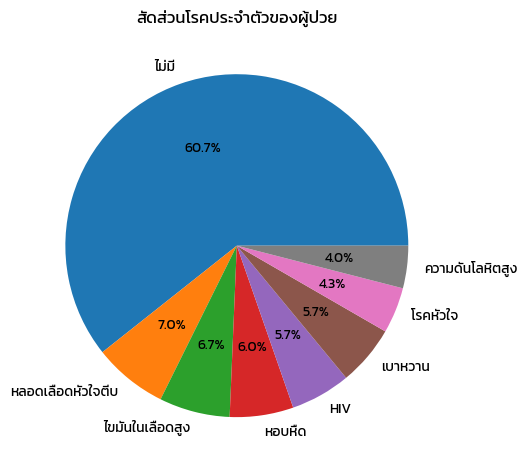

In [22]:
#วิเคราะห์ข้อมูลสัดส่วนของโรคประจำตัวผู้ป่วยด้วย pie chart
print(f'จะเห็นได้ว่าสัดส้วนของโรคประจำส่วนใหญ่คือไม่มี แต่ที่น่าสนใจคือโรคหลอดเลือดหัวใจตีบนั้นกลับมีสัดส่วนมากที่สุดจจากผู้ที่มีโรคประจำตัวทั้งหมด\n\n')
patient_info["โรคประจำตัว"].value_counts().plot(
    kind="pie", autopct="%.1f%%", title="สัดส่วนโรคประจำตัวของผู้ป่วย"
)
plt.ylabel("")
plt.tight_layout()
plt.show()

##4.แสดงจำนวนคนไข้ที่หมอต้องรับผิดชอบต่อคน


 จะเห็นได้จากกราฟว่า พญ. วิภาดา รักษาดี มีการรับผิดชอบคนไช้เยอะที่สุดจากประวัติการรักษาทั้งหมด 




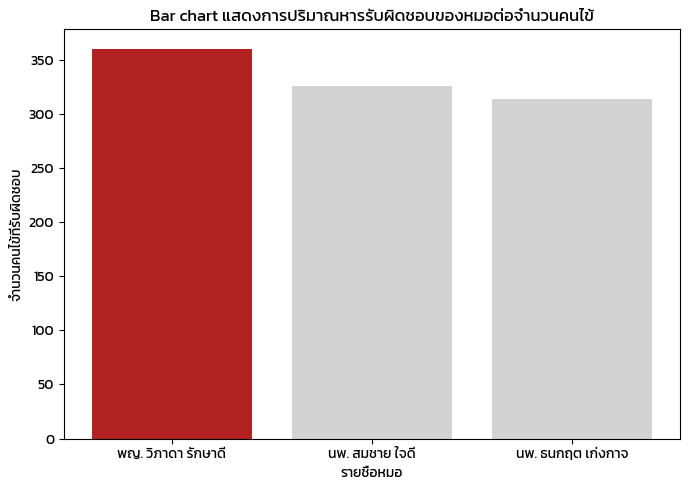

In [23]:
#แสดงจำนวนคนไข้ที่หมอต้องรับผิดชอบต่อคน
DOC_respone_count = Clinic_df.groupby("ชื่อหมอ")["รหัสผู้ป่วย"].count().sort_values(ascending=False)
colors = ["firebrick"] + ["lightgray"] * (len(DOC_respone_count) - 1)

print('\n จะเห็นได้จากกราฟว่า พญ. วิภาดา รักษาดี มีการรับผิดชอบคนไช้เยอะที่สุดจากประวัติการรักษาทั้งหมด \n\n')
plt.figure(figsize=(7, 5))
plt.bar(DOC_respone_count.index, DOC_respone_count.values, color=colors)
plt.title(f"Bar chart แสดงการปริมาณหารรับผิดชอบของหมอต่อจำนวนคนไข้")
plt.xlabel("รายชื่อหมอ")
plt.ylabel("จำนวนคนไข้ที่รับผิดชอบ")
plt.tight_layout()
plt.show()

##5.bar chart แสดงการมีโรคประจำตัว เป็น HIV ตามช่วงอายุ

จะเห็นได้จากกราฟว่าช่วงอายุที่มีเชื่้อ HIV มากที่สุด คือวัยทำงานหรือว่าวัยผู้ใหญ่ ซึ่งสมเหตุสมผลกับความเป็นจริง
จากผู้ที่มีโรคประจำตัว HIV ทั้งหมด : 17 




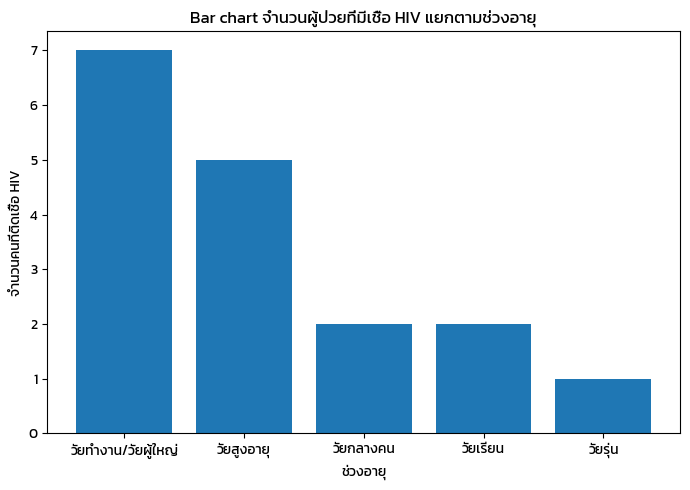

In [24]:
#bar chart แสดงการมีโรคประจำตัว เป็น HIV ตามช่วงอายุ
HIV_count = (patient_info[patient_info["โรคประจำตัว"] == "HIV"].groupby("age_range")["รหัสผู้ป่วย"].count().sort_values(ascending=False))

print('จะเห็นได้จากกราฟว่าช่วงอายุที่มีเชื่้อ HIV มากที่สุด คือวัยทำงานหรือว่าวัยผู้ใหญ่ ซึ่งสมเหตุสมผลกับความเป็นจริง')
print(f'จากผู้ที่มีโรคประจำตัว HIV ทั้งหมด : {HIV_count.sum()} \n\n')
plt.figure(figsize=(7, 5))
plt.bar(HIV_count.index, HIV_count.values, )
plt.title(f"Bar chart จำนวนผู้ป่วยที่มีเชื้อ HIV แยกตามช่วงอายุ")
plt.xlabel("ช่วงอายุ")
plt.ylabel("จำนวนคนที่ติดเชื้อ HIV")
plt.tight_layout()
plt.show()


# วิเคราะห์ข้อมูลด้วย SQL

## เชื่อมต่อและสำรวจข้อมูลตารางทั้งหมดในไฟล์ database

In [25]:
# เชื่อมต่อกับไฟล์ .db ที่สร้างไว้
conn = sqlite3.connect("Clinic_database.db")

sql_query_med = """
SELECT *
FROM medical_records;
"""

# รันคำสั่ง SQL
result_df_med = pd.read_sql(sql_query_med, conn)
display(result_df_med)

conn.close()

,รหัสการรักษา,เวลารักษา,รหัสผู้ป่วย,รหัสหมอ,ชื่อหมอ,การวินิจฉัย,ยาที่สั่ง,สถานะรักษา
0,T001,2026-09-02 15:48:28,P069,DOC003,นพ. ธนกฤต เก่งกาจ,ภาวะช็อกจากการเสียเลือดรุนแรง (Hypovolemic Shock),"IV Fluid Loading, Stop Bleeding",ส่งตัวรักษาต่อโรงพยาบาล (ออกใบรีเฟอร์)
1,T002,2026-09-02 15:01:57,P242,DOC003,นพ. ธนกฤต เก่งกาจ,กล้ามเนื้ออักเสบ (Myalgia / Office Syndrome),"Ibuprofen 400mg, Muscle Relaxant",หายขาด
2,T003,2026-09-02 12:46:51,P200,DOC002,พญ. วิภาดา รักษาดี,รับวัคซีนป้องกันโรคตามกำหนด,"Influenza Vaccine, Paracetamol 500mg (สำรองเผื...",หายขาด
3,T004,2026-09-02 08:01:41,P118,DOC003,นพ. ธนกฤต เก่งกาจ,การบาดเจ็บรุนแรงจากอุบัติเหตุ (Major Trauma),"C-spine Immobilization, Morphine IV, NSS",ส่งตัวรักษาต่อโรงพยาบาล (ออกใบรีเฟอร์)
4,T005,2026-09-02 08:33:14,P278,DOC001,นพ. สมชาย ใจดี,กล้ามเนื้ออักเสบ (Myalgia / Office Syndrome),"Ibuprofen 400mg, Muscle Relaxant",อาการดีขึ้น
...,...,...,...,...,...,...,...,...
995,T996,2026-09-02 08:33:02,P230,DOC001,นพ. สมชาย ใจดี,กล้ามเนื้ออักเสบ (Myalgia / Office Syndrome),"Analgesic Cream, Paracetamol 500mg",หายขาด
996,T997,2026-09-02 12:11:02,P095,DOC001,นพ. สมชาย ใจดี,รับวัคซีนป้องกันโรคตามกำหนด,Hepatitis B Vaccine,หายขาด
997,T998,2026-09-02 16:50:52,P055,DOC002,พญ. วิภาดา รักษาดี,ภาวะชักเกร็งต่อเนื่อง (Status Epilepticus),"Midazolam IM, Oxygen Therapy",ส่งตัวรักษาต่อโรงพยาบาล (ออกใบรีเฟอร์)
998,T999,2026-09-02 11:21:37,P044,DOC003,นพ. ธนกฤต เก่งกาจ,ติดเชื้อทางเดินหายใจส่วนบน (Common Cold),"Paracetamol 500mg, CPM",หายขาด


In [26]:
# เชื่อมต่อกับไฟล์ .db ที่สร้างไว้
conn = sqlite3.connect("Clinic_database.db")

sql_query_patient = """
SELECT *
FROM patients_model;
"""

# รันคำสั่ง SQL
result_df_patient = pd.read_sql(sql_query_patient, conn)
display(result_df_patient.head())

conn.close()

,รหัสผู้ป่วย,ชื่อ - นามสกุล,วันเกิด,อายุ,เบอร์โทรศัพท์,ประวัติแพ้ยา,โรคประจำตัว
0,P001,สมศักดิ์ ประสาน,1945-08-25,81,818470054,ไม่มี,ไม่มี
1,P002,สมปอง ประดิษฐ์,1981-05-08,45,873383683,ซัลฟา,ไม่มี
2,P003,สมหญิง ประจักร,2019-02-18,7,862319252,อัลโลพูรินอล,ไม่มี
3,P004,สมหวัง ประจักร,1997-10-12,28,840703945,ไม่มี,เบาหวาน
4,P005,สมชัย ประสม,2019-05-24,7,897180606,ไม่มี,หอบหืด


In [ ]:
# เชื่อมต่อกับไฟล์ .db ที่สร้างไว้
conn = sqlite3.connect("Clinic_database.db")


sql_query_bill = """
SELECT *
FROM patients_bills;
"""

# รันคำสั่ง SQL
result_df_bill = pd.read_sql(sql_query_bill, conn)
display(result_df_bill.head())

conn.close()

,รหัสใบแจ้งหนี้,รหัสการรักษา,รหัสผู้ป่วย,ค่าบริการ,ค่ายา,ยอดชำระรวม,สถานะการชำระเงิน
0,B0001,T001,P069,300.0,882.0,1182.0,ชำระแล้ว
1,B0002,T002,P242,400.0,420.0,820.0,รอชำระเงิน
2,B0003,T003,P200,500.0,110.0,610.0,รอชำระเงิน
3,B0004,T004,P118,300.0,396.0,696.0,รอชำระเงิน
4,B0005,T005,P278,200.0,1155.0,1355.0,รอชำระเงิน


## 1.อาการยอดฮิต: 5 อันดับแรกของ อาการที่มา ที่พบได้บ่อยที่สุดในคลินิก/โรงพยาบาลคืออะไร

In [27]:
# อาการยอดฮิต: 5 อันดับแรกของ อาการที่มา ที่พบได้บ่อยที่สุดในคลินิก/โรงพยาบาลคืออะไร
conn = sqlite3.connect("Clinic_database.db")

sql_query1 = """
SELECT
    การวินิจฉัย,
    COUNT(การวินิจฉัย) AS จำนวนครั้งการมารักษาแยกตามอาการ,
    SUM(ยอดชำระรวม) AS ยอดชำระรวมทั้งหมดแยกตามอาการที่มารักษา
FROM medical_records
LEFT JOIN patients_bills
ON medical_records.รหัสการรักษา = patients_bills.รหัสการรักษา
GROUP BY การวินิจฉัย
ORDER BY จำนวนครั้งการมารักษาแยกตามอาการ DESC
LIMIT 5;
"""

# รันคำสั่ง SQL
result_df1 = pd.read_sql(sql_query1, conn)
display(result_df1)

conn.close()

,การวินิจฉัย,จำนวนครั้งการมารักษาแยกตามอาการ,ยอดชำระรวมทั้งหมดแยกตามอาการที่มารักษา
0,แผลฉีกขาด (Laceration Wound),59,61594.0
1,ติดเชื้อในระบบทางเดินอาหาร / ไส้ติ่งอักเสบระยะแรก,58,47582.0
2,กล้ามเนื้ออักเสบ (Myalgia / Office Syndrome),57,43365.0
3,รับวัคซีนป้องกันโรคตามกำหนด,54,39043.0
4,ปวดศีรษะไมเกรนรุนแรง / ความดันโลหิตสูงเฉียบพลัน,54,46484.0


##	2.สรุปยอดเงิน: ยอดชำระรวมทั้งหมด (ยอดชำระรวม) และยอดค้างชำระ (แยกตาม สถานะการชำระเงิน) เป็นจำนวนเท่าใด (patients_bills)

In [ ]:
#	สรุปยอดเงิน: ยอดชำระรวมทั้งหมด (ยอดชำระรวม) และยอดค้างชำระ (แยกตาม สถานะการชำระเงิน) เป็นจำนวนเท่าใด (patients_bills)
conn = sqlite3.connect("Clinic_database.db")

sql_query2 = """
SELECT
    สถานะการชำระเงิน,
    SUM(ยอดชำระรวม) AS ยอดชำระรวมทั้งหมดแยกตามสถานะการชำระเงิน
FROM patients_bills
GROUP BY สถานะการชำระเงิน
ORDER BY ยอดชำระรวมทั้งหมดแยกตามสถานะการชำระเงิน DESC;
"""

# รันคำสั่ง SQL
result_df2 = pd.read_sql(sql_query2, conn)
display(result_df2)

conn.close()

,สถานะการชำระเงิน,ยอดชำระรวมทั้งหมดแยกตามสถานะการชำระเงิน
0,ชำระแล้ว,669124.0
1,รอชำระเงิน,207640.0


## 3.รายได้ตามแพทย์: แพทย์คนใดทำยอดรวมค่าบริการ (ค่าบริการ) หรือยอดรวมบิลสูงที่สุด

In [28]:
# รายได้ตามแพทย์: แพทย์คนใดทำยอดรวมค่าบริการ (ค่าบริการ) หรือยอดรวมบิลสูงที่สุด
conn = sqlite3.connect("Clinic_database.db")

sql_query3 = """
SELECT
    ชื่อหมอ,
    SUM(ยอดชำระรวม) AS ยอดชำระรวมทั้งหมดแยกตามสถานะการชำระเงิน
FROM medical_records
LEFT JOIN patients_bills
ON medical_records.รหัสการรักษา = patients_bills.รหัสการรักษา
GROUP BY ชื่อหมอ
ORDER BY ยอดชำระรวมทั้งหมดแยกตามสถานะการชำระเงิน DESC;
"""

# รันคำสั่ง SQL
result_df3 = pd.read_sql(sql_query3, conn)
display(result_df3)

conn.close()

,ชื่อหมอ,ยอดชำระรวมทั้งหมดแยกตามสถานะการชำระเงิน
0,พญ. วิภาดา รักษาดี,313602.0
1,นพ. สมชาย ใจดี,288504.0
2,นพ. ธนกฤต เก่งกาจ,274658.0


## 4.จำนวนการรักษาที่ นพ. ธนกฤต เก่งกาจ รักษาอาการ กระดูกแขนหัก / ข้อต่อหลุด (Fracture/Dislocation)ซึ่งตรงกับความเชี่ยวชาญมากที่สุด เทียบกับเคสทั้งหมดที่ได้รับ

In [29]:
# จำนวนการรักษาที่ นพ. ธนกฤต เก่งกาจ รักษาอาการ กระดูกแขนหัก / ข้อต่อหลุด (Fracture/Dislocation) ซึ่งตรงกับความเชี่ยวชาญมากที่สุด เทียบกับเคสทั้งหมดที่ได้รับ
conn = sqlite3.connect("Clinic_database.db")

sql_query4 = """
SELECT
    ชื่อหมอ,
    COUNT(CASE WHEN การวินิจฉัย LIKE '%สงสัยกระดูกแขนหัก / ข้อต่อหลุด (Fracture/Dislocation)%' THEN 1 END) AS ได้รับเคสตรงความเชี่ยวชาญ,
    COUNT(รหัสการรักษา) AS เคสทั้งหมดที่ได้รับ
FROM medical_records
WHERE ชื่อหมอ = 'นพ. ธนกฤต เก่งกาจ'
GROUP BY ชื่อหมอ;
"""

# รันคำสั่ง SQL
result_df4 = pd.read_sql(sql_query4, conn)
display(result_df4)

conn.close()

,ชื่อหมอ,ได้รับเคสตรงความเชี่ยวชาญ,เคสทั้งหมดที่ได้รับ
0,นพ. ธนกฤต เก่งกาจ,17,314


## 5.จำนวนของคนไข้ที่มีโรคประจำตัว หลอดเลือดหัวใจตีบ ในอายุที่มากกว่า 60 ปี

In [30]:
# จำนวนของคนไข้ที่มีโรคประจำตัว หลอดเลือดหัวใจตีบ ในอายุที่มากกว่า 60 ปี
conn = sqlite3.connect("Clinic_database.db")

sql_query5 = """
SELECT
    โรคประจำตัว,
    COUNT(โรคประจำตัว) AS โรคหลอดเลือดหัวใจตีบในผู้สูงอายุ
FROM patients_model
WHERE โรคประจำตัว = 'หลอดเลือดหัวใจตีบ' AND อายุ >= 60
GROUP BY โรคประจำตัว;
"""

# รันคำสั่ง SQL
result_df5 = pd.read_sql(sql_query5, conn)
display(result_df5)

conn.close()

,โรคประจำตัว,โรคหลอดเลือดหัวใจตีบในผู้สูงอายุ
0,หลอดเลือดหัวใจตีบ,6


## 6.ค้นหาผู้ป่วยวัยทำงาน (อายุ 20 - 40 ปี) ที่มียอดค้างชำระค่ารักษา

In [31]:
# ค้นหาผู้ป่วยวัยทำงาน (อายุ 20 - 40 ปี) ที่มียอดค้างชำระค่ารักษา
conn = sqlite3.connect("Clinic_database.db")

sql_query6 = """
SELECT
    patients_model.รหัสผู้ป่วย,
    "ชื่อ - นามสกุล",
    อายุ,
    เบอร์โทรศัพท์,
    ยอดชำระรวม,
    สถานะการชำระเงิน
FROM patients_bills
LEFT JOIN patients_model
ON patients_bills.รหัสผู้ป่วย = patients_model.รหัสผู้ป่วย
WHERE อายุ BETWEEN 20 AND 40  AND สถานะการชำระเงิน = 'รอชำระเงิน';
"""

# รันคำสั่ง SQL
result_df6 = pd.read_sql(sql_query6, conn)
display(result_df6)

conn.close()

,รหัสผู้ป่วย,ชื่อ - นามสกุล,อายุ,เบอร์โทรศัพท์,ยอดชำระรวม,สถานะการชำระเงิน
0,P118,สมใจ ประเสริฐฐาน,35,886694028,696.0,รอชำระเงิน
1,P278,สมควร ประสงค์,39,894772253,1355.0,รอชำระเงิน
2,P241,สมศรี ประสาน,22,877513769,447.0,รอชำระเงิน
3,P164,สมหมาย ประชาโชค,29,844875501,1220.0,รอชำระเงิน
4,P174,สมฤดี ประเสริฐ,27,853676344,1245.0,รอชำระเงิน
...,...,...,...,...,...,...
74,P119,สมสวย ประเสริฐฐาน,39,837368880,251.0,รอชำระเงิน
75,P049,สมบัตร ประสงค์,28,822939273,899.0,รอชำระเงิน
76,P007,สมปอง ประสิทธิ์,25,856399124,965.0,รอชำระเงิน
77,P007,สมปอง ประสิทธิ์,25,856399124,622.0,รอชำระเงิน


#สิ้นสุดการนำเสนอทั้งหมดขอขอบคุณค่าาาาาาาาาาา🥰
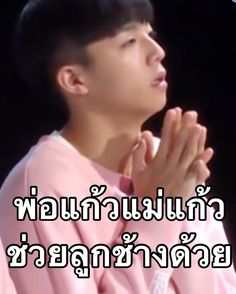